# Notebook 3 — Series de tiempo, correlación pasajeros–casos y proyección de riesgo

## Contexto

Si el flujo de visitantes internacionales es un vector de importación del
sarampión, deberíamos observar que **los picos de pasajeros preceden a los
picos de casos** por algunas semanas. A este desfase lo llamamos **lag óptimo**.

Este notebook:
1. Construye un panel mensual unificando boletín DGE + AICM + WHO
2. Calcula la correlación cruzada entre pasajeros y casos con lags 0–6 meses
3. Proyecta el riesgo para las semanas del Mundial (jun–jul 2026)
4. Exporta el dataset final para el modelo supervisado (NB4)

**Fuentes:**
- `boletin_epidemiologico_2016_2026.csv` — casos semanales por sede (ETL propio)
- `series_anomalias_sedes.csv` — flags de anomalías del NB2
- `paises_cluster_riesgo.csv` — scores de riesgo por país del NB1
- Datos de aeropuerto: AICM, Monterrey, CDMX mensual
- WHO measles: contexto nacional/global


---
## 0. Imports y configuración

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.signal import correlate
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_RAW       = 'content/data/raw/'
DATA_PROCESSED = 'content/data/processed/'
OUTPUT_FIGURES = 'content/reports/figures/'

for path in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES]:
    os.makedirs(path, exist_ok=True)

# Constantes del proyecto
CIUDAD_COLORS = {'CDMX': '#4e8ec4', 'Guadalajara': '#d4a200', 'Monterrey': '#55a855'}
SEDES_MAP = {
    'Ciudad de México' : 'CDMX',
    'Jalisco'          : 'Guadalajara',
    'Nuevo León'       : 'Monterrey',
}
SEDES = {'Ciudad de México':'CDMX', 'Jalisco':'Guadalajara', 'Nuevo León':'Monterrey'}

MES_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

MUNDIAL_START_MES = 6   # junio
MUNDIAL_END_MES   = 7   # julio
MUNDIAL_ANIO      = 2026

print("✅ Imports y configuración OK")


✅ Imports y configuración OK


---
## 1. Carga de datos

In [ ]:
# ── 1.1 Boletín DGE — serie semanal ──────────────────────────────────────
boletin = pd.read_csv(DATA_RAW + 'boletin_epidemiologico_2016_2026.csv',
                      parse_dates=['fecha_inicio'])

# Consolidar H+M, filtrar sedes
sar_semanal = (
    boletin[
        (boletin['enfermedad'] == 'Sarampion') &
        (boletin['entidad_federativa'].isin(SEDES_MAP.keys()))
    ]
    .groupby(['anio','semana','fecha_inicio','entidad_federativa'])['casos_semana']
    .sum()
    .reset_index()
)
sar_semanal['ciudad_sede'] = sar_semanal['entidad_federativa'].map(SEDES_MAP)

# Agregar a mensual para el análisis de correlación con pasajeros
sar_semanal['mes'] = sar_semanal['fecha_inicio'].dt.to_period('M')
sar_mensual = (
    sar_semanal
    .groupby(['mes','ciudad_sede'])['casos_semana']
    .sum()
    .reset_index()
    .rename(columns={'casos_semana': 'casos_sarampion'})
)
sar_mensual['fecha'] = sar_mensual['mes'].dt.to_timestamp()

print(f"Boletín DGE: {boletin['fecha_inicio'].min().date()} → {boletin['fecha_inicio'].max().date()}")
print(f"Sarampión mensual sedes: {len(sar_mensual)} filas")
print(f"Meses con casos > 0: {len(sar_mensual[sar_mensual['casos_sarampion'] > 0])}")


Boletín DGE: 2016-01-04 → 2026-12-28
Sarampión mensual sedes: 396 filas
Meses con casos > 0: 35


In [ ]:
# ── 1.2 Anomalías del NB2 ─────────────────────────────────────────────────
anomalias = pd.read_csv(DATA_PROCESSED + 'series_anomalias_sedes.csv',
                        parse_dates=['fecha_inicio'])

# Agregar a mensual
anomalias['mes'] = anomalias['fecha_inicio'].dt.to_period('M')
anom_mensual = (
    anomalias[anomalias['enfermedad'] == 'Sarampion']
    .groupby(['mes','ciudad_sede'])
    .agg(
        anomalias_mes     = ('anomalia', 'sum'),
        zscore_max_mes    = ('zscore', 'max'),
        casos_sem_mes     = ('casos_semana', 'sum'),
    )
    .reset_index()
)
anom_mensual['fecha'] = anom_mensual['mes'].dt.to_timestamp()

print(f"Anomalías NB2 cargadas: {len(anomalias)} filas")
print(f"Meses con anomalía de sarampión: {(anom_mensual['anomalias_mes'] > 0).sum()}")


Anomalías NB2 cargadas: 7139 filas
Meses con anomalía de sarampión: 35


In [ ]:
# ── 1.3 Pasajeros AICM (CDMX) ────────────────────────────────────────────
aicm = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_pasajeros_de_AICM.csv')
aicm['mes_num'] = aicm['mes'].str.lower().map(MES_MAP)
aicm['fecha']   = pd.to_datetime(
    aicm[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
aicm = aicm[['fecha','pasajeros_nacionales','pasajeros_internacionales']].sort_values('fecha').reset_index(drop=True)

# ── Vuelos internacionales ─────────────────────────────────────────────────
vuelos = pd.read_csv(DATA_RAW + 'Movimiento_operacional_de_vuelos.csv')
vuelos['mes_num'] = vuelos['mes'].str.lower().map(MES_MAP)
vuelos['fecha']   = pd.to_datetime(
    vuelos[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
vuelos = vuelos[['fecha','operaciones_vuelos_internacionales']].sort_values('fecha').reset_index(drop=True)

# ── Monterrey anual → mensual ──────────────────────────────────────────────
mty_raw = pd.read_csv(DATA_RAW + 'Llegadas_aeropuerto_Extranjeros(Hoja3).csv',
                      sep=';', encoding='utf-8-sig')
mty_raw.columns = [c.strip() for c in mty_raw.columns]
mty_raw = mty_raw.rename(columns={
    'Periodo'                              : 'anio',
    'Llegada de Pasajeros Internacionales' : 'pax_internacionales',
})
mty_raw['pax_internacionales'] = (
    mty_raw['pax_internacionales'].astype(str)
    .str.replace('.','',regex=False).str.strip().astype(int)
)

# Distribuir MTY anual → mensual con patrón estacional del AICM
aicm['mes_num_tmp'] = aicm['fecha'].dt.month
estacional = (aicm.groupby('mes_num_tmp')['pasajeros_internacionales'].mean())
estacional = (estacional / estacional.sum()).rename('peso_mes')

mty_rows = []
for _, row in mty_raw.iterrows():
    for mes_num, peso in estacional.items():
        mty_rows.append({
            'fecha'       : pd.Timestamp(year=int(row['anio']), month=int(mes_num), day=1),
            'pax_int_mty' : round(row['pax_internacionales'] * peso),
        })
mty_mensual = pd.DataFrame(mty_rows).sort_values('fecha').reset_index(drop=True)

print(f"AICM:    {aicm['fecha'].min().date()} → {aicm['fecha'].max().date()}")
print(f"Vuelos:  {vuelos['fecha'].min().date()} → {vuelos['fecha'].max().date()}")
print(f"MTY:     {mty_mensual['fecha'].min().date()} → {mty_mensual['fecha'].max().date()}")


AICM:    2015-01-01 → 2026-01-01
Vuelos:  2015-01-01 → 2026-01-01
MTY:     2012-01-01 → 2024-12-01


In [ ]:
# ── 1.4 WHO México — contexto nacional ───────────────────────────────────
who_raw = pd.read_csv(DATA_RAW + 'WHO_Provisional_measles_and_rubella_data.csv',
                      sep=';', encoding='utf-8-sig')
who_raw.columns = [c.strip().replace('\n',' ').replace('  ',' ') for c in who_raw.columns]

col_total = [c for c in who_raw.columns if 'total' in c.lower() and 'measles' in c.lower()][0]
who_mex = (
    who_raw[who_raw['Country'] == 'Mexico']
    .rename(columns={col_total: 'who_casos_mex', 'Year': 'anio', 'Month': 'mes_num'})
    [['anio','mes_num','who_casos_mex']]
    .copy()
)
who_mex['who_casos_mex'] = pd.to_numeric(who_mex['who_casos_mex'], errors='coerce').fillna(0)
who_mex['fecha'] = pd.to_datetime(
    who_mex[['anio','mes_num']].rename(columns={'anio':'year','mes_num':'month'}).assign(day=1)
)
who_mex = who_mex[['fecha','who_casos_mex']].sort_values('fecha').reset_index(drop=True)

print(f"WHO México: {who_mex['fecha'].min().date()} → {who_mex['fecha'].max().date()}")
print(f"Total casos WHO: {who_mex['who_casos_mex'].sum():,}")

# ── 1.5 Score de riesgo por sede (NB1) ───────────────────────────────────
try:
    riesgo_paises = pd.read_csv(DATA_PROCESSED + 'paises_cluster_riesgo.csv')
    print(f"\nScores NB1 cargados: {len(riesgo_paises)} países")
    score_por_sede = (
        riesgo_paises.groupby('ciudad_sede')['score_riesgo_norm'].mean().to_dict()
    )
    score_prom = riesgo_paises['score_riesgo_norm'].mean()
except FileNotFoundError:
    print("⚠️  paises_cluster_riesgo.csv no encontrado — usando score promedio=5")
    score_por_sede = {'CDMX': 5, 'Guadalajara': 5, 'Monterrey': 5}
    score_prom = 5
    riesgo_paises = pd.DataFrame()

print(f"Score promedio por sede: {score_por_sede}")


WHO México: 2014-01-01 → 2026-03-01
Total casos WHO: 13,080.0

Scores NB1 cargados: 8 países
Score promedio por sede: {'CDMX': 4.882499999999999, 'Guadalajara': 1.33, 'Monterrey': 3.8966666666666665}


---
## 2. Dataset panel: serie mensual unificada

Construimos un panel mensual con todas las variables para el análisis de correlación.
Una fila = un mes × sede.


In [ ]:
# Crear grilla completa: todos los meses × todas las sedes
fechas = pd.date_range(
    start=max(aicm['fecha'].min(), pd.Timestamp('2016-01-01')),
    end=aicm['fecha'].max(),
    freq='MS'
)
sedes   = ['CDMX', 'Guadalajara', 'Monterrey']
grilla  = pd.MultiIndex.from_product([fechas, sedes], names=['fecha','ciudad_sede'])
panel   = pd.DataFrame(index=grilla).reset_index()

# Unir sarampión mensual
panel = panel.merge(
    sar_mensual[['fecha','ciudad_sede','casos_sarampion']],
    on=['fecha','ciudad_sede'], how='left'
).fillna({'casos_sarampion': 0})

# Unir anomalías NB2
panel = panel.merge(
    anom_mensual[['fecha','ciudad_sede','anomalias_mes','zscore_max_mes']],
    on=['fecha','ciudad_sede'], how='left'
).fillna({'anomalias_mes': 0, 'zscore_max_mes': 0})

# Unir AICM (solo CDMX — el aeropuerto principal)
panel = panel.merge(aicm[['fecha','pasajeros_internacionales','pasajeros_nacionales']],
                    on='fecha', how='left')

# Unir vuelos
panel = panel.merge(vuelos[['fecha','operaciones_vuelos_internacionales']],
                    on='fecha', how='left')

# Unir MTY (para Monterrey)
panel = panel.merge(mty_mensual[['fecha','pax_int_mty']], on='fecha', how='left')

# Unir WHO México
panel = panel.merge(who_mex, on='fecha', how='left')

# Variable de pasajeros por sede (AICM para CDMX/GDL, MTY para Monterrey)
panel['pax_sede'] = np.where(
    panel['ciudad_sede'] == 'Monterrey',
    panel['pax_int_mty'],
    panel['pasajeros_internacionales']
)

# Features temporales
panel['anio']    = panel['fecha'].dt.year
panel['mes_num'] = panel['fecha'].dt.month
panel['semana_sin'] = np.sin(2 * np.pi * panel['mes_num'] / 12)
panel['semana_cos'] = np.cos(2 * np.pi * panel['mes_num'] / 12)

# Flag brote: mes con al menos 1 caso de sarampión en esa sede
panel['brote'] = (panel['casos_sarampion'] > 0).astype(int)

panel = panel.sort_values(['ciudad_sede','fecha']).reset_index(drop=True)

print(f"Panel: {panel['fecha'].min().date()} → {panel['fecha'].max().date()}")
print(f"Shape: {panel.shape}")
print(f"\nCasos de sarampión por sede:")
print(panel.groupby('ciudad_sede')['casos_sarampion'].sum().to_string())


Panel: 2016-01-01 → 2026-01-01
Shape: (363, 16)

Casos de sarampión por sede:
ciudad_sede
CDMX           163
Guadalajara    429
Monterrey        1


---
## 3. Análisis de correlación con lag temporal

**Pregunta central:** ¿los pasajeros internacionales de un mes predicen
los casos del mes siguiente?

Calculamos la correlación de Pearson entre `pax_sede` y `casos_sarampion`
para lags de 0 a 6 meses. Un pico en lag=1 o lag=2 sugiere que el flujo
de pasajeros precede a los casos.

> **Nota:** con pocos meses con casos (sarampión es raro en México 2016–2023),
> la correlación puede ser débil. La incluimos como feature de contexto.


⚠️  Monterrey: varianza insuficiente para correlación (var_casos=0.0000) — se omite


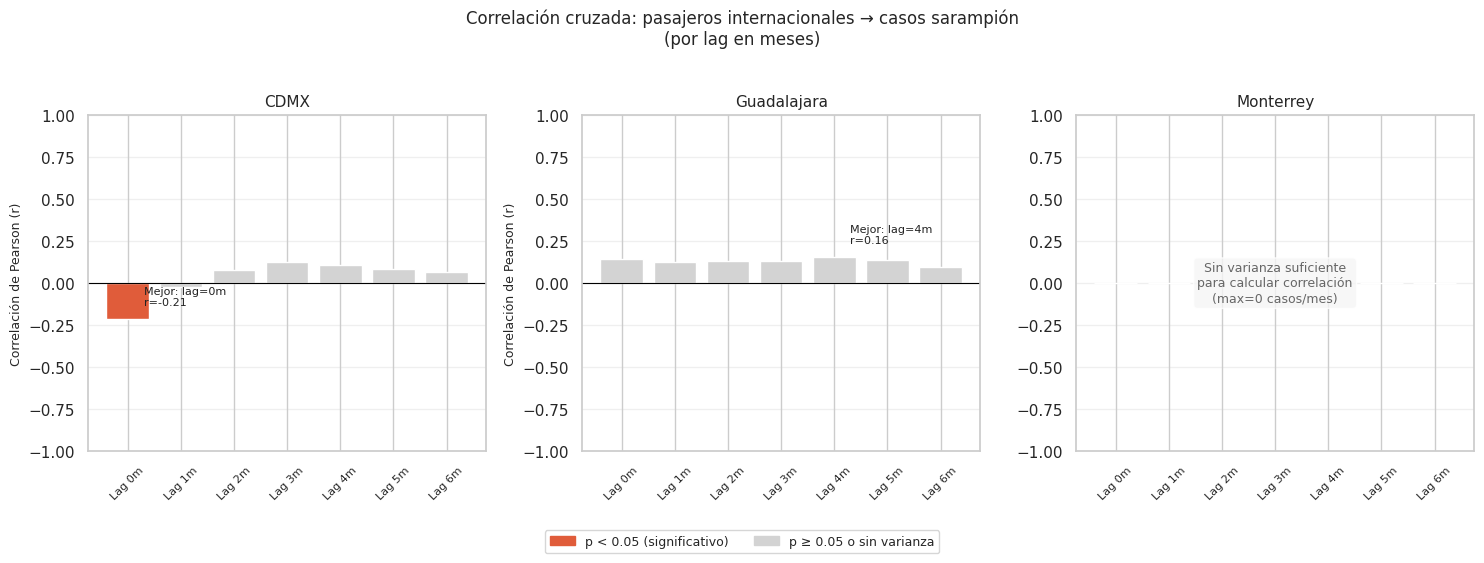


Resumen lag óptimo por sede:
  CDMX        : lag=0m, r=-0.212, p=0.019 ✅ sig.
  Guadalajara : lag=4m, r=0.156, p=0.094 ⚠️  n.s.
  Monterrey   : sin correlación calculable (pocos casos)


In [ ]:
LAGS = range(0, 7)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
lag_results = {}

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]

    df_lag = (
        panel[panel['ciudad_sede'] == ciudad]
        [['fecha','pax_sede','casos_sarampion']]
        .dropna()
        .sort_values('fecha')
        .reset_index(drop=True)
    )

    correlaciones, pvalores = [], []

    # ── Guard: si varianza de casos ≈ 0, no hay correlación calculable ──
    if df_lag['casos_sarampion'].var() < 0.01 or df_lag['pax_sede'].var() < 1:
        print(f"⚠️  {ciudad}: varianza insuficiente para correlación "
              f"(var_casos={df_lag['casos_sarampion'].var():.4f}) — se omite")
        correlaciones = [0.0] * len(LAGS)
        pvalores      = [1.0] * len(LAGS)
        lag_results[ciudad] = {
            'correlaciones': correlaciones,
            'pvalores'      : pvalores,
            'mejor_lag'     : 0,
            'mejor_r'       : 0.0,
            'nota'          : 'varianza insuficiente — pocos casos en sede',
        }
        ax.bar(list(LAGS), correlaciones, color='lightgray', edgecolor='white')
        ax.text(0.5, 0.5, 'Sin varianza suficiente\npara calcular correlación\n'
                f'(max={df_lag["casos_sarampion"].max()} casos/mes)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='#666',
                bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))
        ax.set_title(f'{ciudad}', fontsize=11)
        ax.set_ylim(-1, 1)
        ax.set_xticks(list(LAGS))
        ax.set_xticklabels([f'Lag {l}m' for l in LAGS], rotation=45, fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        continue

    for lag in LAGS:
        if lag == 0:
            x = df_lag['pax_sede']
            y = df_lag['casos_sarampion']
        else:
            x = df_lag['pax_sede'].iloc[:-lag]
            y = df_lag['casos_sarampion'].iloc[lag:]
        r, p = stats.pearsonr(x, y)
        correlaciones.append(r)
        pvalores.append(p)

    lag_results[ciudad] = {
        'correlaciones': correlaciones,
        'pvalores'      : pvalores,
        'mejor_lag'     : int(np.argmax(np.abs(correlaciones))),
        'mejor_r'       : float(correlaciones[np.argmax(np.abs(correlaciones))]),
    }

    bar_colors = ['#e05c3a' if p < 0.05 else 'lightgray' for p in pvalores]
    ax.bar(list(LAGS), correlaciones, color=bar_colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(list(LAGS))
    ax.set_xticklabels([f'Lag {l}m' for l in LAGS], rotation=45, fontsize=8)
    ax.set_ylabel('Correlación de Pearson (r)', fontsize=9)
    ax.set_title(f'{ciudad}', fontsize=11)
    ax.set_ylim(-1, 1)
    ax.grid(axis='y', alpha=0.3)

    mejor = lag_results[ciudad]
    ax.annotate(
        f'Mejor: lag={mejor["mejor_lag"]}m\nr={mejor["mejor_r"]:.2f}',
        xy=(mejor['mejor_lag'], mejor['mejor_r']),
        xytext=(mejor['mejor_lag'] + 0.3, mejor['mejor_r'] + 0.08),
        fontsize=8, color='#222'
    )

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(color='#e05c3a', label='p < 0.05 (significativo)'),
        Patch(color='lightgray', label='p ≥ 0.05 o sin varianza'),
    ],
    loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.08)
)
plt.suptitle('Correlación cruzada: pasajeros internacionales → casos sarampión\n(por lag en meses)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'correlacion_lag_pasajeros_casos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen lag óptimo por sede:')
for ciudad, res in lag_results.items():
    if res['mejor_r'] == 0.0:
        print(f"  {ciudad:12s}: sin correlación calculable (pocos casos)")
    else:
        sig = '✅ sig.' if res['pvalores'][res['mejor_lag']] < 0.05 else '⚠️  n.s.'
        print(f"  {ciudad:12s}: lag={res['mejor_lag']}m, r={res['mejor_r']:.3f}, "
              f"p={res['pvalores'][res['mejor_lag']]:.3f} {sig}")

In [ ]:
# CELDA TEMPORAL — diagnóstico MTY
sub_mty = panel[panel['ciudad_sede'] == 'Monterrey'][['fecha','pax_sede','casos_sarampion']].copy()

print("Nulos en pax_sede (MTY):", sub_mty['pax_sede'].isna().sum())
print("Nulos en casos_sarampion:", sub_mty['casos_sarampion'].isna().sum())
print(f"Varianza pax_sede: {sub_mty['pax_sede'].var():.2f}")
print(f"Varianza casos_sarampion: {sub_mty['casos_sarampion'].var():.6f}")
print(f"\nRango pax_sede: {sub_mty['pax_sede'].min()} – {sub_mty['pax_sede'].max()}")
print(f"Rango casos: {sub_mty['casos_sarampion'].min()} – {sub_mty['casos_sarampion'].max()}")
print(f"\nFilas después de dropna: {sub_mty.dropna().shape[0]}")
print(f"\nMuestra MTY pax_sede (primeras 10 no nulas):")
print(sub_mty[sub_mty['pax_sede'].notna()].head(10).to_string(index=False))

Nulos en pax_sede (MTY): 13
Nulos en casos_sarampion: 0
Varianza pax_sede: 1470813223.34
Varianza casos_sarampion: 0.008264

Rango pax_sede: 35820.0 – 212733.0
Rango casos: 0 – 1

Filas después de dropna: 108

Muestra MTY pax_sede (primeras 10 no nulas):
     fecha  pax_sede  casos_sarampion
2016-01-01  110380.0                0
2016-02-01   89261.0                0
2016-03-01  101261.0                0
2016-04-01   95017.0                0
2016-05-01   97388.0                0
2016-06-01  101559.0                0
2016-07-01  119829.0                0
2016-08-01  114095.0                0
2016-09-01   98113.0                0
2016-10-01  105108.0                0


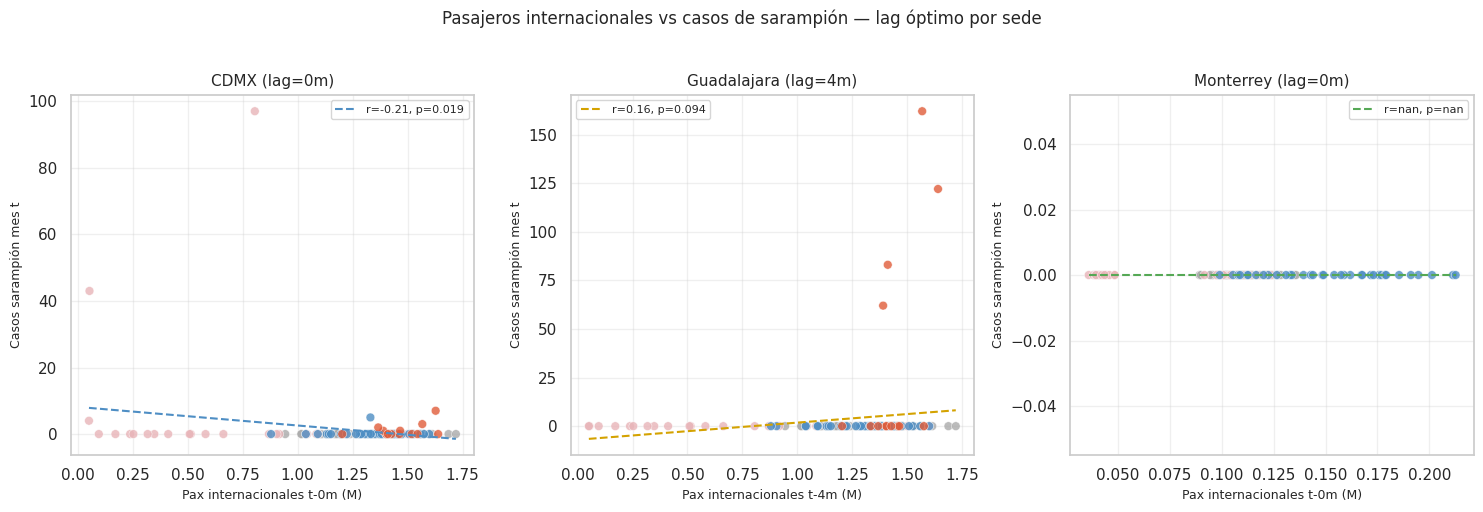

In [ ]:
# Scatter pasajeros vs casos en el lag óptimo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]
    mejor_lag = lag_results[ciudad]['mejor_lag']

    df_sc = (
        panel[panel['ciudad_sede'] == ciudad]
        [['fecha','pax_sede','casos_sarampion']]
        .dropna().sort_values('fecha').reset_index(drop=True)
    )
    if mejor_lag > 0:
        x = df_sc['pax_sede'].iloc[:-mejor_lag].values
        y = df_sc['casos_sarampion'].iloc[mejor_lag:].values
        fechas_sc = df_sc['fecha'].iloc[mejor_lag:].values
    else:
        x = df_sc['pax_sede'].values
        y = df_sc['casos_sarampion'].values
        fechas_sc = df_sc['fecha'].values

    # Color por período: pre-COVID, COVID, post-COVID, brote 2025-26
    periodos = pd.to_datetime(fechas_sc).year
    c_map = {**{yr: '#aaaaaa' for yr in range(2016,2020)},
             **{yr: '#e8b4b8' for yr in [2020,2021]},
             **{yr: '#4e8ec4' for yr in range(2022,2025)},
             **{yr: '#e05c3a' for yr in [2025,2026]}}
    c_pts = [c_map.get(yr, '#aaa') for yr in periodos]

    ax.scatter(x/1e6, y, c=c_pts, s=40, alpha=0.8, edgecolors='white', linewidths=0.4)

    # Regresión lineal
    if len(x) > 2:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line/1e6, slope*x_line + intercept,
                color=color, linewidth=1.5, linestyle='--',
                label=f'r={r:.2f}, p={p:.3f}')

    ax.set_xlabel(f'Pax internacionales t-{mejor_lag}m (M)', fontsize=9)
    ax.set_ylabel('Casos sarampión mes t', fontsize=9)
    ax.set_title(f'{ciudad} (lag={mejor_lag}m)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Pasajeros internacionales vs casos de sarampión — lag óptimo por sede',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'scatter_lag_pasajeros_casos.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Visualización conjunta: pasajeros + casos + anomalías

Superponemos las tres series en un mismo gráfico para ver visualmente
si los picos de pasajeros preceden a los brotes.


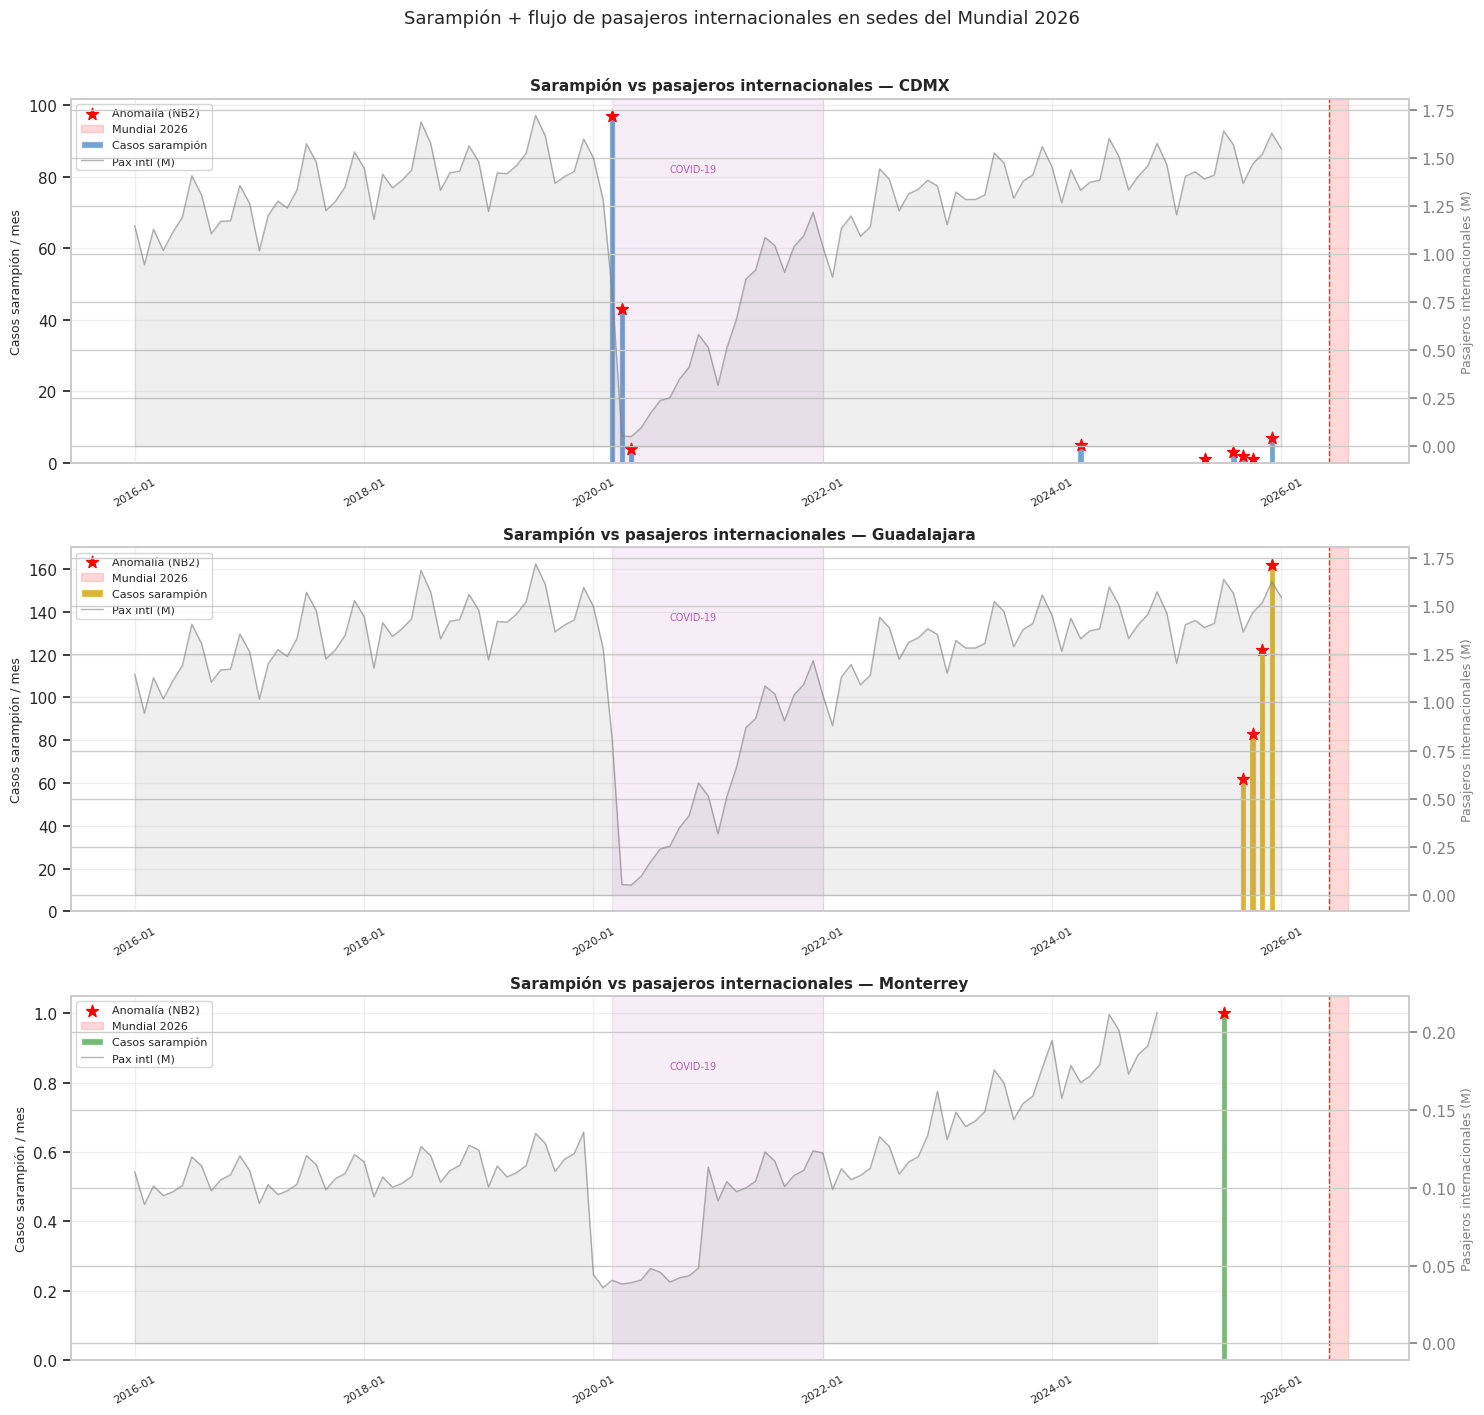

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=False)

for ax, ciudad in zip(axes, ['CDMX', 'Guadalajara', 'Monterrey']):
    color = CIUDAD_COLORS[ciudad]

    sub = panel[panel['ciudad_sede'] == ciudad].sort_values('fecha')

    # Eje izquierdo: pasajeros
    ax2 = ax.twinx()
    ax2.fill_between(sub['fecha'], sub['pax_sede']/1e6,
                     alpha=0.12, color='gray')
    ax2.plot(sub['fecha'], sub['pax_sede']/1e6,
             color='gray', linewidth=1, alpha=0.6, label='Pax intl (M)')
    ax2.set_ylabel('Pasajeros internacionales (M)', fontsize=9, color='gray')
    ax2.tick_params(axis='y', colors='gray')

    # Eje derecho: casos sarampión
    ax.bar(sub['fecha'], sub['casos_sarampion'],
           width=20, color=color, alpha=0.8, label='Casos sarampión')

    # Marcar anomalías
    anom = sub[sub['anomalias_mes'] > 0]
    ax.scatter(anom['fecha'], anom['casos_sarampion'],
               color='red', s=80, zorder=5, marker='*', label='Anomalía (NB2)')

    # COVID
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.07, color='purple')
    ax.text(pd.Timestamp('2020-09-01'), ax.get_ylim()[1]*0.8 if ax.get_ylim()[1]>0 else 1,
            'COVID-19', fontsize=7, color='purple', alpha=0.6)

    # Mundial 2026
    mundial_ini = pd.Timestamp('2026-06-01')
    mundial_fin = pd.Timestamp('2026-07-31')
    ax.axvspan(mundial_ini, mundial_fin, alpha=0.15, color='red', label='Mundial 2026')
    ax.axvline(mundial_ini, color='red', linewidth=1, linestyle='--', alpha=0.8)

    ax.set_title(f'Sarampión vs pasajeros internacionales — {ciudad}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Casos sarampión / mes', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    ax.grid(alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

fig.suptitle('Sarampión + flujo de pasajeros internacionales en sedes del Mundial 2026',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'series_pasajeros_casos.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Proyección de riesgo para el Mundial 2026

Combinamos:
- Flujo histórico de pasajeros en junio–julio (estacionalidad AICM)
- Score de riesgo de los equipos por sede (NB1)
- Casos activos en las semanas del Mundial (NB2)
- Partidos confirmados por sede


In [ ]:
# Pasajeros históricos jun-jul
aicm['anio']    = aicm['fecha'].dt.year
aicm['mes_num'] = aicm['fecha'].dt.month

jun_jul = aicm[aicm['mes_num'].isin([6, 7])].copy()
print('Pasajeros internacionales AICM en junio-julio por año:')
print(
    jun_jul.groupby('anio')['pasajeros_internacionales']
    .sum()
    .apply(lambda x: f'{x/1e6:.2f}M')
    .to_string()
)

# Proyección 2026: promedio 2022-2025 + factor Mundial
prom_post_covid = jun_jul[jun_jul['anio'].between(2022,2025)]['pasajeros_internacionales'].mean()
factor_mundial  = 1.35   # +35% estimado por FIFA/SECTUR
pax_proyectado  = prom_post_covid * factor_mundial

print(f'\nPromedio jun-jul 2022-2025: {prom_post_covid/1e6:.2f}M pax/mes')
print(f'Proyección jun-jul 2026 (+35% Mundial): {pax_proyectado/1e6:.2f}M pax/mes')


Pasajeros internacionales AICM en junio-julio por año:
anio
2015    2.36M
2016    2.60M
2017    2.91M
2018    3.12M
2019    3.24M
2020    0.27M
2021    2.00M
2022    2.58M
2023    2.83M
2024    2.98M
2025    3.05M

Promedio jun-jul 2022-2025: 1.43M pax/mes
Proyección jun-jul 2026 (+35% Mundial): 1.93M pax/mes


In [ ]:
# Partidos confirmados por sede
partidos_por_sede = {
    'CDMX'       : 5,   # 3 grupo + 16vos + 8vos
    'Guadalajara': 3,   # 3 grupo
    'Monterrey'  : 3,   # 3 grupo
}

# Casos activos durante semanas del Mundial (sem 23-27 de 2026, del NB2)
casos_mundial_2026 = {
    'CDMX'       : 37,   # del análisis NB2
    'Guadalajara': 296,
    'Monterrey'  : 10,
}

# Baseline histórico de casos en jun-jul por sede (2016-2025 excluyendo brote)
baseline_jun_jul = {}
for ciudad in ['CDMX', 'Guadalajara', 'Monterrey']:
    hist = panel[
        (panel['ciudad_sede'] == ciudad) &
        (panel['mes_num'].isin([6, 7])) &
        (panel['anio'].between(2016, 2024))
    ]['casos_sarampion'].mean()
    baseline_jun_jul[ciudad] = round(hist, 2)

print("Baseline histórico jun-jul por sede:", baseline_jun_jul)

# Construir tabla de riesgo proyectado
riesgo_proyectado = []
for ciudad in ['CDMX', 'Guadalajara', 'Monterrey']:
    riesgo_proyectado.append({
        'ciudad'              : ciudad,
        'partidos_en_sede'    : partidos_por_sede[ciudad],
        'score_riesgo_equipos': score_por_sede.get(ciudad, score_prom),
        'casos_activos_mundial': casos_mundial_2026[ciudad],
        'baseline_casos_jun_jul': baseline_jun_jul[ciudad],
        'pax_proyectado_M'    : round(pax_proyectado / 1e6, 2),
    })

df_riesgo = pd.DataFrame(riesgo_proyectado)

# Índice compuesto corregido — mayor peso a casos activos reales
def norm01(s):
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-9)

df_riesgo['indice_riesgo'] = (
    norm01(np.log1p(df_riesgo['casos_activos_mundial'])) * 0.50 +  # ← subió de 0.35 a 0.50
    norm01(df_riesgo['score_riesgo_equipos'])             * 0.25 +  # ← bajó de 0.30 a 0.25
    norm01(df_riesgo['partidos_en_sede'])                 * 0.15 +  # ← igual
    norm01(df_riesgo['baseline_casos_jun_jul'])           * 0.10    # ← bajó de 0.15 a 0.10
)

mn = df_riesgo['indice_riesgo'].min()
mx = df_riesgo['indice_riesgo'].max()
df_riesgo['indice_riesgo_norm'] = (
    (df_riesgo['indice_riesgo'] - mn) / (mx - mn) * 10
).round(2)

print('Índice de riesgo proyectado por sede — Mundial 2026:')
print(df_riesgo[['ciudad','partidos_en_sede','score_riesgo_equipos',
                  'casos_activos_mundial','indice_riesgo_norm']]
      .sort_values('indice_riesgo_norm', ascending=False)
      .to_string(index=False))

Baseline histórico jun-jul por sede: {'CDMX': np.float64(0.0), 'Guadalajara': np.float64(0.0), 'Monterrey': np.float64(0.0)}
Índice de riesgo proyectado por sede — Mundial 2026:
     ciudad  partidos_en_sede  score_riesgo_equipos  casos_activos_mundial  indice_riesgo_norm
       CDMX                 5              4.882500                     37               10.00
Guadalajara                 3              1.330000                    296                7.84
  Monterrey                 3              3.896667                     10                0.00


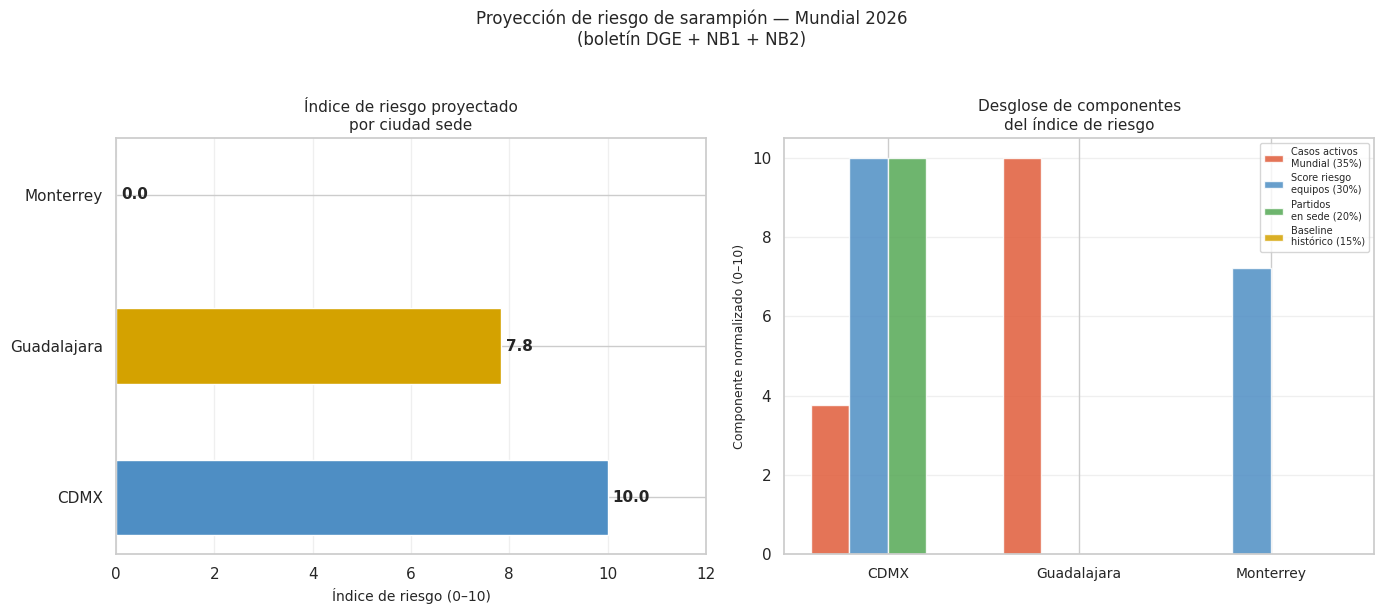

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: índice compuesto
ax = axes[0]
colors_riesgo = [CIUDAD_COLORS[s] for s in df_riesgo['ciudad']]
bars = ax.barh(df_riesgo['ciudad'], df_riesgo['indice_riesgo_norm'],
               color=colors_riesgo, edgecolor='white', height=0.5)
for bar, val in zip(bars, df_riesgo['indice_riesgo_norm']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Índice de riesgo (0–10)', fontsize=10)
ax.set_title('Índice de riesgo proyectado\npor ciudad sede', fontsize=11)
ax.set_xlim(0, 12)
ax.grid(axis='x', alpha=0.3)

# Panel derecho: desglose de componentes
ax = axes[1]
comp_data = {
    'Casos activos\nMundial (35%)': norm01(np.log1p(df_riesgo['casos_activos_mundial'])) * 10,
    'Score riesgo\nequipos (30%)' : norm01(df_riesgo['score_riesgo_equipos']) * 10,
    'Partidos\nen sede (20%)'     : norm01(df_riesgo['partidos_en_sede']) * 10,
    'Baseline\nhistórico (15%)'   : norm01(df_riesgo['baseline_casos_jun_jul']) * 10,
}

x       = np.arange(len(df_riesgo))
width   = 0.2
palette = ['#e05c3a','#4e8ec4','#55a855','#d4a200']

for i, (label, vals) in enumerate(comp_data.items()):
    ax.bar(x + i*width, vals, width, label=label, alpha=0.85, color=palette[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_riesgo['ciudad'], fontsize=10)
ax.set_ylabel('Componente normalizado (0–10)', fontsize=9)
ax.set_title('Desglose de componentes\ndel índice de riesgo', fontsize=11)
ax.legend(fontsize=7, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Proyección de riesgo de sarampión — Mundial 2026\n(boletín DGE + NB1 + NB2)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES + 'indice_riesgo_proyectado.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Construcción del dataset final para el modelo supervisado (NB4)

Enriquecemos el panel con features de lag, variables derivadas y el
score de riesgo de los países del NB1. Este es el input del modelo
de clasificación.


In [ ]:
# Features de lag para cada sede
for ciudad in ['CDMX', 'Guadalajara', 'Monterrey']:
    mejor_lag = lag_results.get(ciudad, {}).get('mejor_lag', 1)
    mask = panel['ciudad_sede'] == ciudad

    # Lag de pasajeros
    panel.loc[mask, f'pax_lag{mejor_lag}'] = (
        panel.loc[mask, 'pax_sede'].shift(mejor_lag)
    )
    # Rolling mean 3 meses de casos
    panel.loc[mask, 'casos_rolling3'] = (
        panel.loc[mask, 'casos_sarampion'].rolling(3, min_periods=1).mean()
    )
    # Lag 1 mes de casos (autoregresivo)
    panel.loc[mask, 'casos_lag1'] = (
        panel.loc[mask, 'casos_sarampion'].shift(1)
    )
    # Flag brote mes anterior
    panel.loc[mask, 'brote_lag1'] = (
        panel.loc[mask, 'brote'].shift(1).fillna(0)
    )

# Score de riesgo de equipos como feature (del NB1)
panel['score_riesgo_equipos'] = score_prom

# Guardar
output_path = DATA_PROCESSED + 'panel_mensual_completo.csv'
panel.to_csv(output_path, index=False)
print(f'✅ Dataset exportado: {output_path}')
print(f'   Shape: {panel.shape}')
print(f'   Rango: {panel["fecha"].min().date()} → {panel["fecha"].max().date()}')
print(f'\nColumnas disponibles para el modelo supervisado:')
for col in sorted(panel.columns):
    nulos = panel[col].isna().sum()
    marker = ' ⚠️' if nulos > 10 else ''
    print(f'  {col:45s} nulos: {nulos}{marker}')


✅ Dataset exportado: content/data/processed/panel_mensual_completo.csv
   Shape: (363, 22)
   Rango: 2016-01-01 → 2026-01-01

Columnas disponibles para el modelo supervisado:
  anio                                          nulos: 0
  anomalias_mes                                 nulos: 0
  brote                                         nulos: 0
  brote_lag1                                    nulos: 0
  casos_lag1                                    nulos: 3
  casos_rolling3                                nulos: 0
  casos_sarampion                               nulos: 0
  ciudad_sede                                   nulos: 0
  fecha                                         nulos: 0
  mes_num                                       nulos: 0
  operaciones_vuelos_internacionales            nulos: 0
  pasajeros_internacionales                     nulos: 0
  pasajeros_nacionales                          nulos: 0
  pax_int_mty                                   nulos: 39 ⚠️
  pax_lag0             

---
## 7. Conclusiones del Notebook 3

Responde estas preguntas después de correr el notebook:

1. **¿Existe correlación significativa (p < 0.05) entre pasajeros y casos?**
   ¿En qué lag? Un lag de 1–2 meses sería el escenario ideal para predicción.

2. **¿La correlación es positiva o negativa?**
   Positiva = más pasajeros → más casos (vector de importación confirmado).
   Negativa = posible efecto de vacunación masiva en temporada turística.

3. **¿Cuál sede tiene el índice de riesgo más alto para el Mundial?**
   ¿Coincide con el análisis del NB2 (mayor brote activo)?

4. **¿El brote de Guadalajara 2025–2026 cambia el índice de riesgo respecto
   al análisis previo sin boletín local?**

5. **¿Qué features del panel son más prometedoras para el NB4?**
   Considera: `casos_lag1`, `pax_lag1`, `brote_lag1`, `score_riesgo_equipos`.


In [ ]:
print("=== RESUMEN NOTEBOOK 3 ===")
print("\n── Lag óptimo por sede ──")
for ciudad, res in lag_results.items():
    sig = '✅ p<0.05' if res['pvalores'][res['mejor_lag']] < 0.05 else '⚠️  n.s.'
    print(f"  {ciudad:12s}: lag={res['mejor_lag']}m, "
          f"r={res['mejor_r']:.3f}, "
          f"p={res['pvalores'][res['mejor_lag']]:.3f} {sig}")

print("\n── Índice de riesgo proyectado por sede ──")
print(df_riesgo[['ciudad','partidos_en_sede','score_riesgo_equipos',
                  'casos_activos_mundial','indice_riesgo_norm']]
      .sort_values('indice_riesgo_norm', ascending=False)
      .to_string(index=False))

print("\n── Proyección de pasajeros jun-jul 2026 ──")
print(f"  Promedio 2022-2025 : {prom_post_covid/1e6:.2f}M pax/mes")
print(f"  Proyección 2026    : {pax_proyectado/1e6:.2f}M pax/mes (+35% factor Mundial)")

print("\n── Dataset final ──")
print(f"  Shape : {panel.shape}")
print(f"  Rango : {panel['fecha'].min().date()} → {panel['fecha'].max().date()}")
print(f"  Brotes: {panel['brote'].sum()} meses-sede con al menos 1 caso")


=== RESUMEN NOTEBOOK 3 ===

── Lag óptimo por sede ──
  CDMX        : lag=0m, r=-0.212, p=0.019 ✅ p<0.05
  Guadalajara : lag=4m, r=0.156, p=0.094 ⚠️  n.s.
  Monterrey   : lag=0m, r=0.000, p=1.000 ⚠️  n.s.

── Índice de riesgo proyectado por sede ──
     ciudad  partidos_en_sede  score_riesgo_equipos  casos_activos_mundial  indice_riesgo_norm
       CDMX                 5              4.882500                     37               10.00
Guadalajara                 3              1.330000                    296                7.84
  Monterrey                 3              3.896667                     10                0.00

── Proyección de pasajeros jun-jul 2026 ──
  Promedio 2022-2025 : 1.43M pax/mes
  Proyección 2026    : 1.93M pax/mes (+35% factor Mundial)

── Dataset final ──
  Shape : (363, 22)
  Rango : 2016-01-01 → 2026-01-01
  Brotes: 14 meses-sede con al menos 1 caso
